In [1]:
print('will see similarity on the basis of Genre')

will see similarity on the basis of Genre


In [2]:
import pandas as pd
import numpy as np


In [3]:
#loading the saved file which was feature engineered

movies = pd.read_parquet(
    "../data/processed/movies_features.parquet"
)

In [4]:
movies.head()

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,genres_test,genres_text,num_genres,release_year
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,Animation Children Comedy,Animation Children Comedy,3,1995.0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,1,0,0,Action Adventure Thriller,Action Adventure Thriller,3,1995.0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,Thriller,Thriller,1,1995.0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,Action Comedy Drama,Action Comedy Drama,3,1995.0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,Crime Drama Thriller,Crime Drama Thriller,3,1995.0


In [5]:
movies.drop(columns=["genres_test"], inplace=True)

In [6]:
movies[['movie_id','title','genres_text']].head()

,movie_id,title,genres_text
0,1,Toy Story (1995),Animation Children Comedy
1,2,GoldenEye (1995),Action Adventure Thriller
2,3,Four Rooms (1995),Thriller
3,4,Get Shorty (1995),Action Comedy Drama
4,5,Copycat (1995),Crime Drama Thriller


In [7]:
movies['genres_text']=(
    movies['genres_text']
    .str.replace('Sci-Fi','SciFi')
    .str.replace('Film-Noir','FilmNoir')
)

In [8]:
#conveting genres into vectors to apply TF_IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

tfidf_matrix=tfidf.fit_transform(
    movies['genres_text']
)



In [9]:
tfidf_matrix.shape

(1682, 19)

In [10]:
#understanding vocab

tfidf.get_feature_names_out()

array(['action', 'adventure', 'animation', 'children', 'comedy', 'crime',
       'documentary', 'drama', 'fantasy', 'filmnoir', 'horror', 'musical',
       'mystery', 'romance', 'scifi', 'thriller', 'unknown', 'war',
       'western'], dtype=object)

In [11]:
#compute similarity

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix=cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

In [12]:
print(similarity_matrix)

[[1.         0.         0.         ... 0.         0.34941857 0.        ]
 [0.         1.         0.53676706 ... 0.         0.         0.        ]
 [0.         0.53676706 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.53394963]
 [0.34941857 0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.53394963 0.         1.        ]]


In [13]:
similarity_matrix.shape

(1682, 1682)

<Axes: >

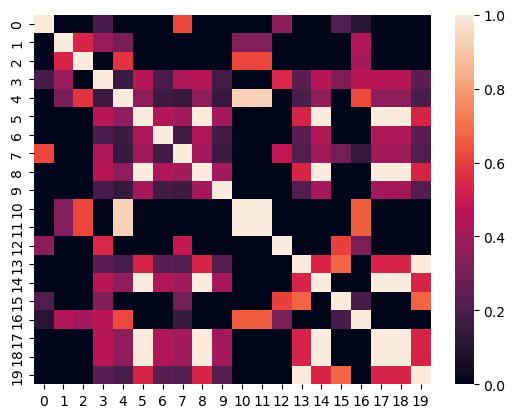

In [14]:
import seaborn as sns

sns.heatmap(
    similarity_matrix[:20, :20]
)

In [15]:
similarity_matrix[5][50] #similarity b/w movie 50 and movie 50 

np.float64(0.2480037786742468)

# Recommndation Logic

In [16]:
def get_movie_index(title):
    title = title.strip().lower()

    # 1. Exact match first (BEST CASE)
    exact_match = movies[movies["title"].str.lower() == title]

    if len(exact_match) > 0:
        return exact_match.index[0]

    # 2. Fallback: partial match
    matches = movies[movies["title"].str.lower().str.contains(title, regex=False)]

    if len(matches) == 0:
        return None

    return matches.index[0]

In [17]:
def recommend_movies(title, top_n=10):

    idx = get_movie_index(title)

    if idx is None:
        return "Movie not found"

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    movie_indices_list = [i[0] for i in similarity_scores]

    return movies.iloc[movie_indices_list][
        ['title', 'genres_text']
    ]

In [18]:
movies[movies["title"] == "Toy Story (1995)"][["title", "genres_text"]]

,title,genres_text
0,Toy Story (1995),Animation Children Comedy


In [19]:
recommend_movies(
    "Toy Story (1995)"
)

,title,genres_text
421,Aladdin and the King of Thieves (1996),Animation Children Comedy
101,"Aristocats, The (1970)",Animation Children
403,Pinocchio (1940),Animation Children
624,"Sword in the Stone, The (1963)",Animation Children
945,"Fox and the Hound, The (1981)",Animation Children
968,Winnie the Pooh and the Blustery Day (1968),Animation Children
1065,Balto (1995),Animation Children
1077,Oliver & Company (1988),Animation Children
1408,"Swan Princess, The (1994)",Animation Children
1411,Land Before Time III: The Time of the Great Gi...,Animation Children


In [20]:
title = "Toy Story (1995)".strip().lower()

idx = movies[movies["title"].str.lower() == title].index[0]

In [21]:
similarity_scores = list(enumerate(similarity_matrix[idx]))

top_movies = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[1:11]

In [22]:
movie_indices_list = [i[0] for i in top_movies]

movies.iloc[movie_indices_list][["title", "genres_text"]]

,title,genres_text
421,Aladdin and the King of Thieves (1996),Animation Children Comedy
101,"Aristocats, The (1970)",Animation Children
403,Pinocchio (1940),Animation Children
624,"Sword in the Stone, The (1963)",Animation Children
945,"Fox and the Hound, The (1981)",Animation Children
968,Winnie the Pooh and the Blustery Day (1968),Animation Children
1065,Balto (1995),Animation Children
1077,Oliver & Company (1988),Animation Children
1408,"Swan Princess, The (1994)",Animation Children
1411,Land Before Time III: The Time of the Great Gi...,Animation Children


In [23]:
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

similarity_scores[1:11]

[(421, np.float64(1.0)),
 (101, np.float64(0.936966733687292)),
 (403, np.float64(0.936966733687292)),
 (624, np.float64(0.936966733687292)),
 (945, np.float64(0.936966733687292)),
 (968, np.float64(0.936966733687292)),
 (1065, np.float64(0.936966733687292)),
 (1077, np.float64(0.936966733687292)),
 (1408, np.float64(0.936966733687292)),
 (1411, np.float64(0.936966733687292))]

In [24]:
recommend_movies("Toy Story")

,title,genres_text
421,Aladdin and the King of Thieves (1996),Animation Children Comedy
101,"Aristocats, The (1970)",Animation Children
403,Pinocchio (1940),Animation Children
624,"Sword in the Stone, The (1963)",Animation Children
945,"Fox and the Hound, The (1981)",Animation Children
968,Winnie the Pooh and the Blustery Day (1968),Animation Children
1065,Balto (1995),Animation Children
1077,Oliver & Company (1988),Animation Children
1408,"Swan Princess, The (1994)",Animation Children
1411,Land Before Time III: The Time of the Great Gi...,Animation Children


# Saving Essential things

In [25]:
import joblib

joblib.dump(
    similarity_matrix,
    "../data/processed/content_similarity.pkl"
)

['../data/processed/content_similarity.pkl']

In [26]:
movie_indices = pd.Series(
    movies.index,
    index=movies["title"]
).drop_duplicates()

In [27]:
joblib.dump(
    movie_indices,
    "../data/processed/movie_indices.pkl"
)

['../data/processed/movie_indices.pkl']

In [28]:
joblib.dump(
    tfidf,
    "../data/processed/tfidf_vectorizer.pkl"
)

['../data/processed/tfidf_vectorizer.pkl']